In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("data4.csv")

In [11]:
df

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,...,stores,id_games,achievements_count,a_count,series_count,dev_team_count,rating_norm,reviews_log,reviews_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,...,['Steam'],965470,0.0,0.0,0.0,1.0,0.739130,5.379897,0.604780,0.651803
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,...,['Steam'],994601,0.0,0.0,1.0,1.0,0.000000,1.791759,0.201420,0.130923
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,...,"['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,0.948240,6.455199,0.725660,0.803563
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,0.751553,7.799753,0.876807,0.832968
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,0.708075,7.663408,0.861480,0.807788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7418,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.00,...,"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0,0.000000,0.693147,0.077920,0.050648
7419,https://store.steampowered.com/app/1298140/Fob...,Fobia - St. Dinfna Hotel,2022-06-28,Pulsatrix Studios,['Indie'],"24,99€",0%,0.0,"['Indie', 'Survival Horror', 'Puzzle', 'Violen...",3.27,...,"['Steam', 'itch.io']",484814,23.0,0.0,0.0,0.0,0.677019,2.772589,0.311680,0.439548
7420,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0,0.699793,3.091042,0.347479,0.470789
7421,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0,0.000000,1.098612,0.123500,0.080275


In [12]:
df.shape

(7423, 23)

In [13]:
df = df.drop_duplicates()

анализ популярности, вовлеченности и пострелизного развития игры. в этом разделе рассмотрим признаки playtime, achievements_count и a_count и их связь с итоговым показателем успешности игры score

In [14]:
df[["playtime", "achievements_count", "a_count", "score"]].describe()

,playtime,achievements_count,a_count,score
count,7423.000000,7423.000000,7423.000000,7423.000000
mean,4.472181,38.068975,0.302169,0.436272
std,9.477739,116.824781,1.830872,0.244917
min,0.000000,0.000000,0.000000,0.050648
25%,1.000000,0.000000,0.000000,0.130923
50%,3.000000,22.000000,0.000000,0.489062
75%,5.000000,44.000000,0.000000,0.620985
max,466.000000,5609.000000,40.000000,0.986232


признаки плэйтайм и achievements_count имеют сильную правостороннюю асимметрию те у большинства игр значения сравнительно небольшие, но при этом есть отдельные игры с очень высокими показателями. мб длинный хвост распределения и выбросы. у большей части игр а_каунт равно нулю те для большинства не зафиксировано пострелизного расширения. но у части игр все же есть положительные значения поэтому не отметаем от рассмотрения

In [17]:
!pip3 install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 634.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.2 MB/s eta 0:00:00a 0:00:010m

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'количесвто игр')

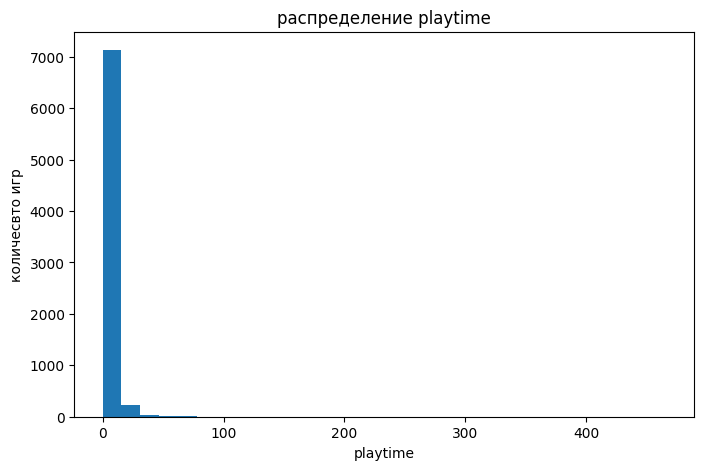

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["playtime"], bins=30)
plt.title("распределение playtime")
plt.xlabel("playtime")
plt.ylabel("количесвто игр")

Text(0, 0.5, 'количество игр')

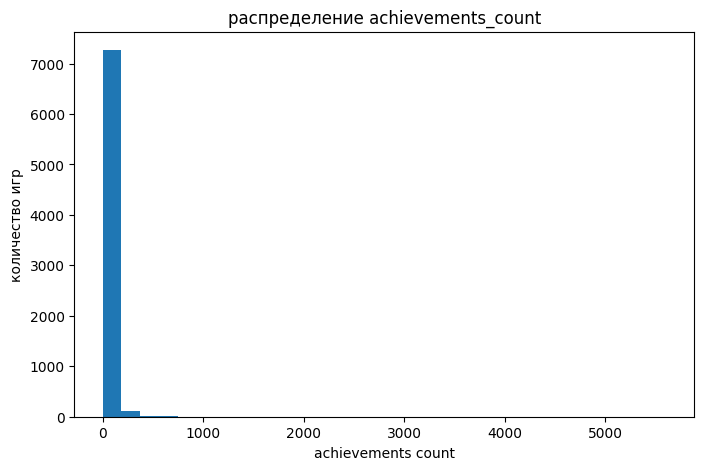

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(df["achievements_count"], bins=30)
plt.title("распределение achievements_count")
plt.xlabel("achievements count")
plt.ylabel("количество игр")

Text(0, 0.5, 'количество игр')

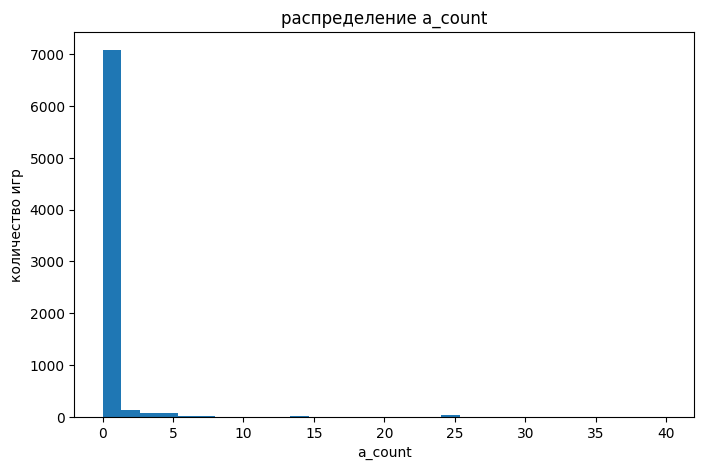

In [49]:
plt.figure(figsize=(8, 5))
plt.hist(df["a_count"], bins=30)
plt.title("распределение a_count")
plt.xlabel('a_count')
plt.ylabel("количество игр")

Text(0, 0.5, 'score')

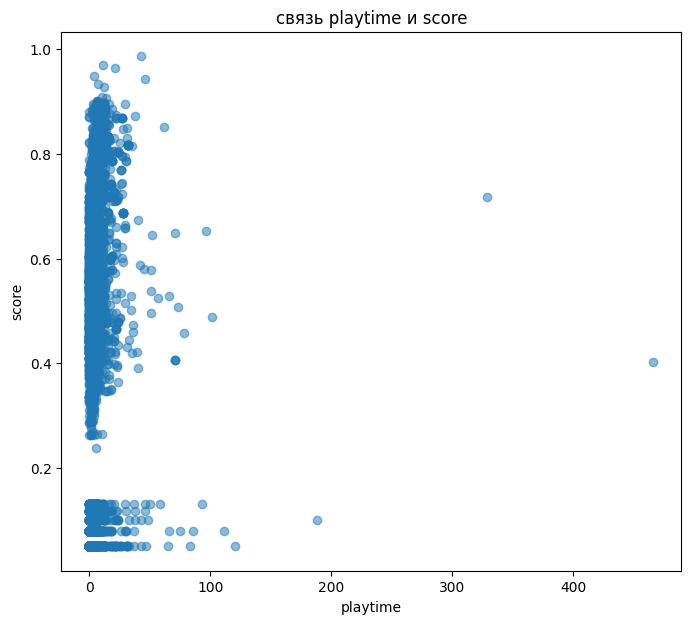

In [8]:
plt.figure(figsize=(8, 7))
plt.scatter(df["playtime"], df["score"], alpha=0.5)
plt.title("связь playtime и score")
plt.xlabel("playtime")
plt.ylabel("score")

здесь явной линейной связи чет совсем не видно. почти все наблюдения собрались при маленьких значениях playtime а дальше идут отдельные редкие точки с большим временем прохождения. в общепм по этому графику не можем сказать, что рост playtime сам по себе как то сопровождается ростом score

Text(0, 0.5, 'score')

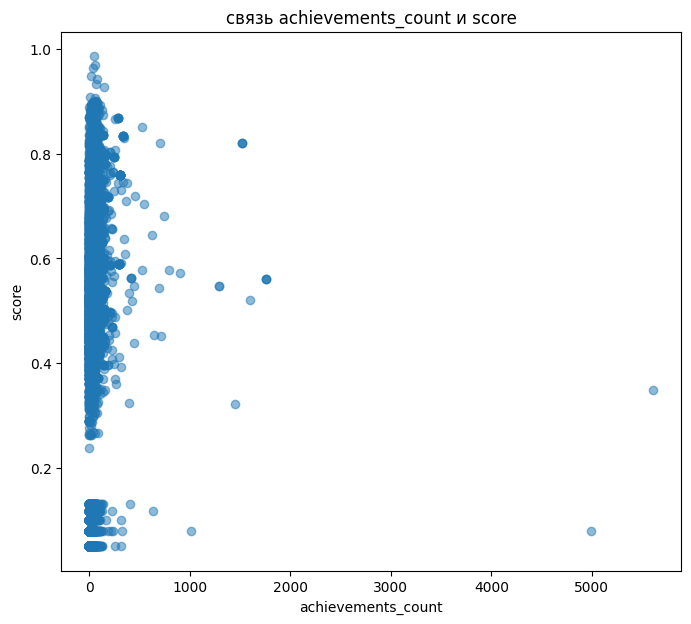

In [9]:
plt.figure(figsize=(8, 7))
plt.scatter(df["achievements_count"], df["score"], alpha=0.5)
plt.title("связь achievements_count и score")
plt.xlabel("achievements_count")
plt.ylabel("score")

нууу картина та же, четкой зависимости чет не прослеживается. у большинства игр небольшое количество достижений, а очень большие значения встречаются редко и выглядят просто как выбросы

Text(0, 0.5, 'score')

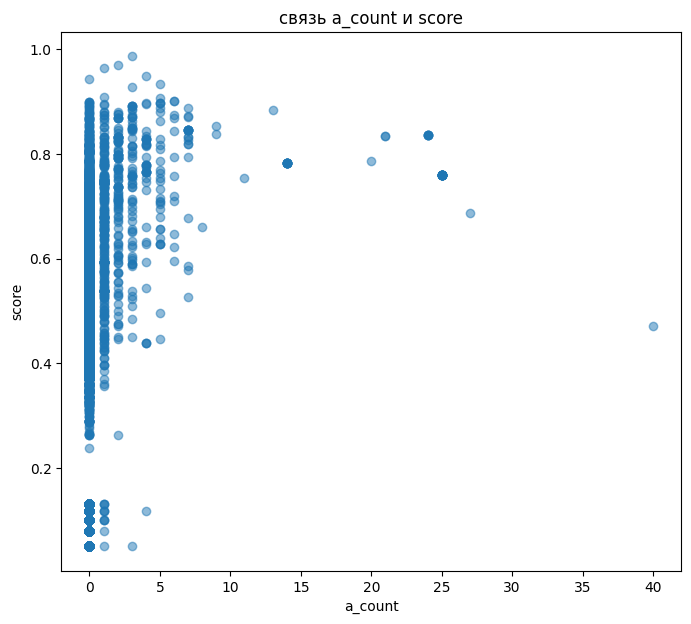

In [10]:
plt.figure(figsize=(8, 7))
plt.scatter(df["a_count"], df["score"], alpha=0.5)
plt.title("связь a_count и score")
plt.xlabel("a_count")
plt.ylabel("score")

тут уже поинтереснее, конечно, связь не прям линейная, нооо отдалеенно можно преположить, что игры с более широким пострелизным расширением чаще имеют более высокий scorrrre

резко подумала, что плэйтайм не может быть ноль тк мы удалили все игры, у которых вообще не отзывов, то есть плэйтайм не ноль. удаляем там где ноль

In [11]:
df_p = df[["playtime", "score"]].copy()
df_p = df_p[df_p["playtime"]!= 0]

In [54]:
df_p

,playtime,score
1,7.0,0.130923
2,24.0,0.803563
3,5.0,0.832968
4,8.0,0.807788
5,21.0,0.963342
...,...,...
7418,10.0,0.050648
7419,4.0,0.439548
7420,4.0,0.470789
7421,3.0,0.080275


Text(0, 0.5, 'score')

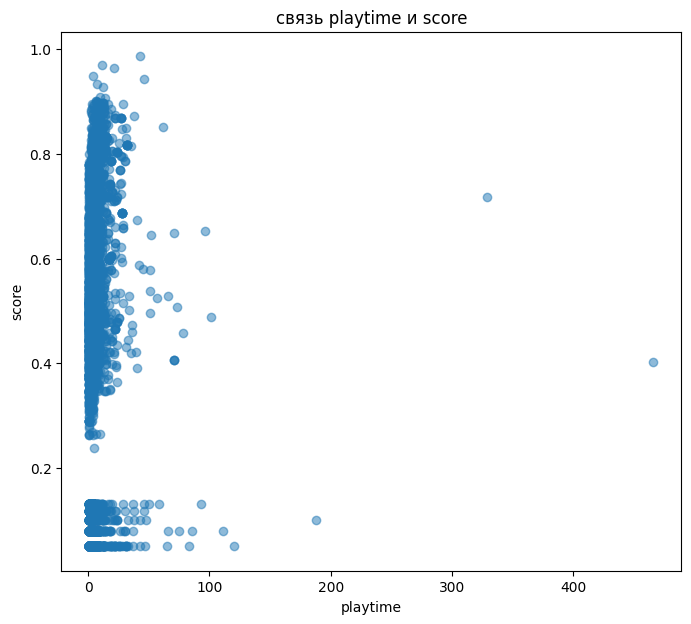

In [12]:
plt.figure(figsize=(8, 7))
plt.scatter(df_p["playtime"], df_p["score"], alpha=0.5)
plt.title("связь playtime и score")
plt.xlabel("playtime")
plt.ylabel("score")

мда ну ладно зависимости совсем не виднеется. явной связи нет(

In [86]:
def group(x):
    if x == 0:
        return '0'
    elif x <= 2:
        return '1-2'
    elif x <= 5:
        return '3-5'
    elif x <= 10:
        return '6-10'
    else:
        return '10+'

In [87]:
df["a_count_group"] = df["a_count"].apply(group)

In [88]:
group = df.groupby('a_count_group').agg({
    'name': ['count'],
    'score': ['mean', 'median']
})

In [89]:
group.columns = ['count', 'mean_score', 'median_score']
group = group.reset_index()

In [90]:
group

,a_count_group,count,mean_score,median_score
0,0,6778,0.412185,0.471343
1,1-2,422,0.655393,0.679697
2,10+,43,0.774397,0.782099
3,3-5,143,0.738965,0.765163
4,6-10,37,0.786801,0.838466


Text(0, 0.5, 'средний score')

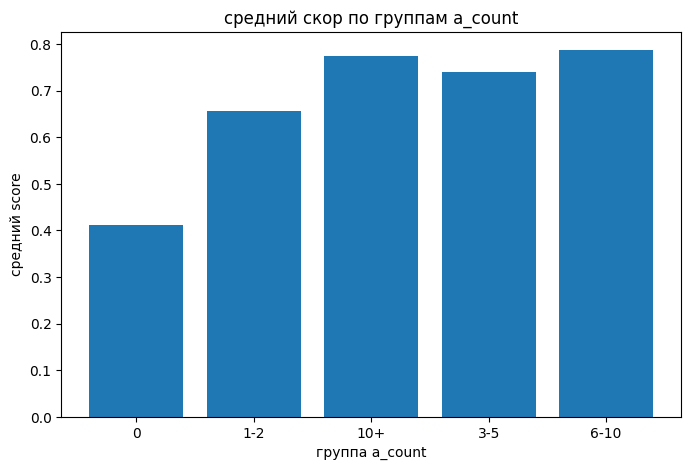

In [91]:
plt.figure(figsize=(8, 5))
plt.bar(group["a_count_group"], group["mean_score"])
plt.title("средний скор по группам a_count")
plt.xlabel("группа a_count")
plt.ylabel("средний score")

блин шо с порядком

In [92]:
order = ["0", "1-2", "3-5", "6-10", "10+"]

In [93]:
group = group.set_index("a_count_group")
group = group.loc[order]
group

,count,mean_score,median_score
a_count_group,,,
0,6778,0.412185,0.471343
1-2,422,0.655393,0.679697
3-5,143,0.738965,0.765163
6-10,37,0.786801,0.838466
10+,43,0.774397,0.782099


In [94]:
group = group.reset_index()
group

,a_count_group,count,mean_score,median_score
0,0,6778,0.412185,0.471343
1,1-2,422,0.655393,0.679697
2,3-5,143,0.738965,0.765163
3,6-10,37,0.786801,0.838466
4,10+,43,0.774397,0.782099


Text(0, 0.5, 'средний score')

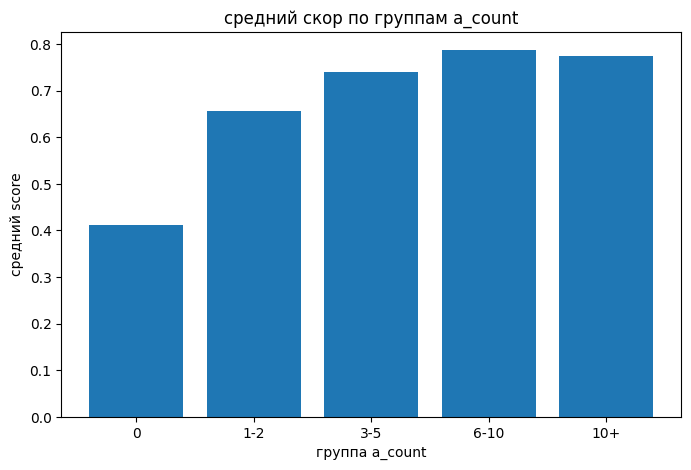

In [95]:
plt.figure(figsize=(8, 5))
plt.bar(group["a_count_group"], group["mean_score"])
plt.title("средний скор по группам a_count")
plt.xlabel("группа a_count")
plt.ylabel("средний score")

ну вот теперь прослеживается довольно четенькая закономерность. у игр без дополнительного связанного контента средний скоре сильно ниже, чем у всех остальных групп. а при переходе к группе 1-2 есть сильный рост, а затем при дальнейшем увеличении скоре продолжает расти, но правда не прям так сильно. после группы 3–5 значения становятся близкими друг к другу, разница уже не такая большая. получается это как в сериалах, когда выходит 100 сезонов, уже говно какое то))

Text(0, 0.5, 'score')

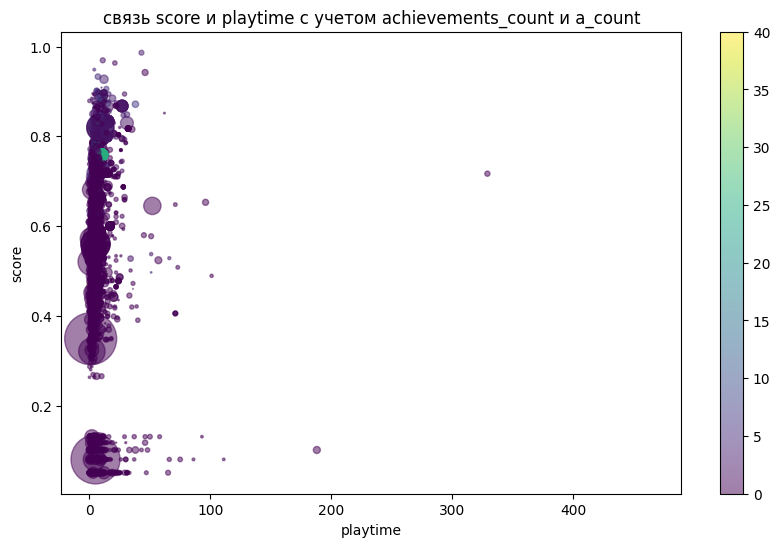

In [104]:
fig, ax = plt.subplots(figsize=(10, 6))

color_graph = ax.scatter(df["playtime"],
                         df["score"],
                         s=df["achievements_count"] / 4,
                         c=df["a_count"],
                         alpha=0.5,
                         cmap="viridis"
)
plt.colorbar(color_graph)
plt.title("связь score и playtime с учетом achievements_count и a_count")
plt.xlabel("playtime")
plt.ylabel("score")

график в общем то подверждает, что не можем говорить о сильной связи этих признаков с скоре. не заметна зависимость от цвета и размера точек, ну и понятно как выше все копится около нуля по playtime, те так же нет зависимости

In [98]:
!pip3 install seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [99]:
import seaborn as sns

In [105]:
corr = df[["playtime", "achievements_count", "a_count", "score"]].corr()
corr

,playtime,achievements_count,a_count,score
playtime,1.000000,0.059592,0.051137,0.115221
achievements_count,0.059592,1.000000,0.116001,0.125081
a_count,0.051137,0.116001,1.000000,0.204023
score,0.115221,0.125081,0.204023,1.000000


Text(0.5, 1.0, 'тепловая карта кореляций')

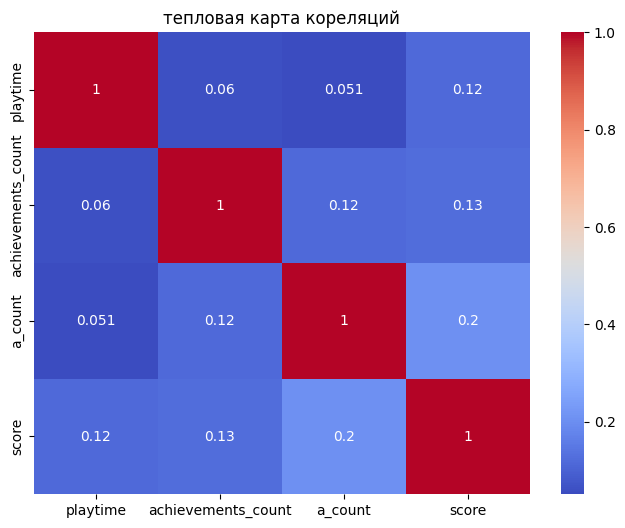

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", annot=True,)
plt.title("тепловая карта кореляций")

все рассмотренные признаки имеют слабую положительную корреляцию со скоре, но самой так скажем заметной среди них является связь a_count и score в целых 0.2. это в общем то соответствует предыдущим графикам. корреляции playtime и achievements_count со score ооочень низкие поэтому говорить что то о мега линейной связи этих признаков с score все так женельзя. а еще между самими признаками сильной зависимости не наблюдается. так шо они описывают разные стороны игр и не дублируют друг друга
ну в общем тепловая карта подтверждает результаты предыдущего анализа. наиболее информативным по отношению к score и правда оказался a_count